In [1]:
import pandas as pd

In [2]:
df_serie_completa = pd.read_excel(r"C:\Users\usuario1\OneDrive - Universidad de Antioquia\UNIVERSIDAD DE ANTIOQUIA\Proyecto SAT Dengue\Bases de datos\Secretaria de salud\BD_DENGUE_2008-2025.xlsx")
df_serie_completa

,cod_eve,fec_not,semana,año,cod_pre,cod_sub,edad_,uni_med_,nacionali_,nombre_nacionalidad,...,nom_upgd,npais_proce,ndep_proce,nmun_proce,npais_resi,ndep_resi,nmun_resi,ndep_notif,nmun_notif,nreg
0,210,2008-04-07,14,2008,500102092,1,35,1,SIN INFORMACIÓN,SIN INFORMACIÓN,...,SIN INFORMACIÓN,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,CAUCASIA,ANTIOQUIA,CAUCASIA,38
1,210,2008-04-25,16,2008,515403817,1,6,1,SIN INFORMACIÓN,SIN INFORMACIÓN,...,CLINICA PAJONAL LIMITADA,COLOMBIA,ANTIOQUIA,SANTAFE DE ANTIOQUIA,COLOMBIA,ANTIOQUIA,CAUCASIA,ANTIOQUIA,CAUCASIA,1
2,210,2008-05-12,18,2008,515403817,1,32,1,SIN INFORMACIÓN,SIN INFORMACIÓN,...,CLINICA PAJONAL LIMITADA,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,CAUCASIA,ANTIOQUIA,CAUCASIA,6
3,210,2008-05-12,16,2008,515407501,0,19,1,SIN INFORMACIÓN,SIN INFORMACIÓN,...,ESE HOSPITAL CESAR URIBE PIEDARHITA,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,CAUCASIA,ANTIOQUIA,CAUCASIA,4
4,210,2008-05-12,16,2008,515407501,0,18,1,SIN INFORMACIÓN,SIN INFORMACIÓN,...,ESE HOSPITAL CESAR URIBE PIEDARHITA,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,CAUCASIA,ANTIOQUIA,CAUCASIA,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9904,210,2026-01-02,2025-12-30 00:00:00,53,2025,515403817,1,5,1,170,...,CLINICA PAJONAL LIMITADA,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,CAUCASIA,ANTIOQUIA,CAUCASIA,2026-01-29 00:00:00
9905,210,2026-01-02,2025-12-31 00:00:00,53,2025,7070800117,1,50,1,170,...,ESE CENTRO DE SALUD SAN JOSE 1 NIVEL SAN MARCOS,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,CAUCASIA,SUCRE,SAN MARCOS,2026-01-05 00:00:00
9906,210,2026-01-01,2026-01-01 00:00:00,53,2025,515402201,1,38,1,170,...,ESE HOSPITAL CESAR URIBE PIEDRAHITA,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,CAUCASIA,ANTIOQUIA,CAUCASIA,2026-01-20 00:00:00
9907,210,2026-01-03,2026-01-01 00:00:00,53,2025,515402201,1,8,1,170,...,ESE HOSPITAL CESAR URIBE PIEDRAHITA,COLOMBIA,ANTIOQUIA,CAUCASIA,COLOMBIA,ANTIOQUIA,CAUCASIA,ANTIOQUIA,CAUCASIA,2026-01-21 00:00:00


In [3]:
df_serie_completa.columns

Index(['cod_eve', 'fec_not', 'semana', 'año', 'cod_pre', 'cod_sub', 'edad_',
       'uni_med_', 'nacionali_', 'nombre_nacionalidad',
       ...
       'nom_upgd', 'npais_proce', 'ndep_proce', 'nmun_proce', 'npais_resi',
       'ndep_resi', 'nmun_resi', 'ndep_notif', 'nmun_notif', 'nreg'],
      dtype='object', length=120)

In [4]:
import pandas as pd

# Asegurar formato fecha
df_serie_completa['fec_not'] = pd.to_datetime(df_serie_completa['fec_not'], errors='coerce')

# Eliminar fechas nulas
df_serie_completa = df_serie_completa.dropna(subset=['fec_not'])

# Crear columna de semana epidemiológica
df_serie_completa['semana_ep'] = df_serie_completa['fec_not'].dt.to_period('W').apply(lambda r: r.start_time)

# Agrupar casos por semana
serie = df_serie_completa.groupby('semana_ep').size().reset_index(name='casos_dengue')

print(serie.head())

   semana_ep  casos_dengue
0 2008-04-07             1
1 2008-04-21             1
2 2008-05-12             7
3 2008-05-19             3
4 2008-05-26             2


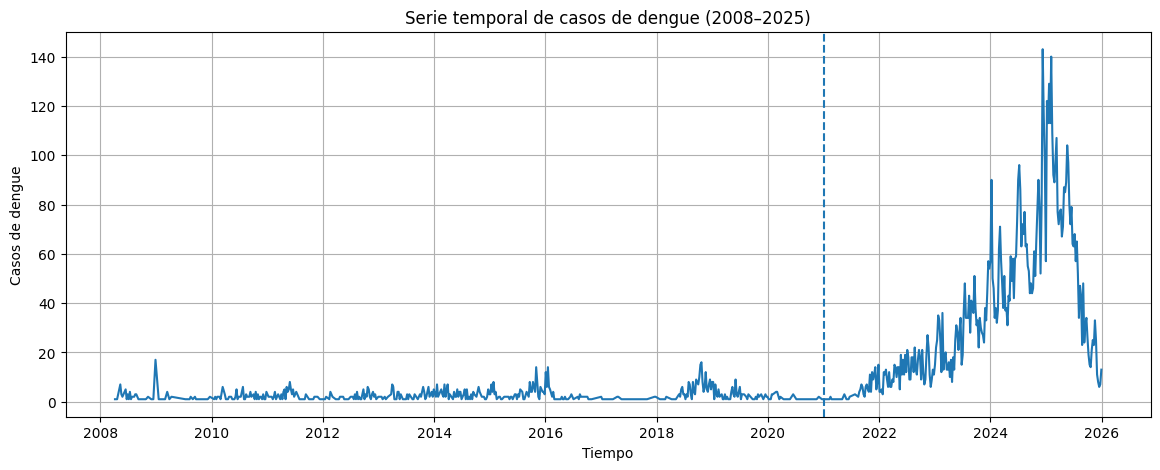

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(serie['semana_ep'], serie['casos_dengue'])

# Línea que marca inicio del análisis
plt.axvline(pd.to_datetime('2021-01-01'), linestyle='--')

plt.title('Serie temporal de casos de dengue (2008–2025)')
plt.xlabel('Tiempo')
plt.ylabel('Casos de dengue')

plt.grid()
plt.show()

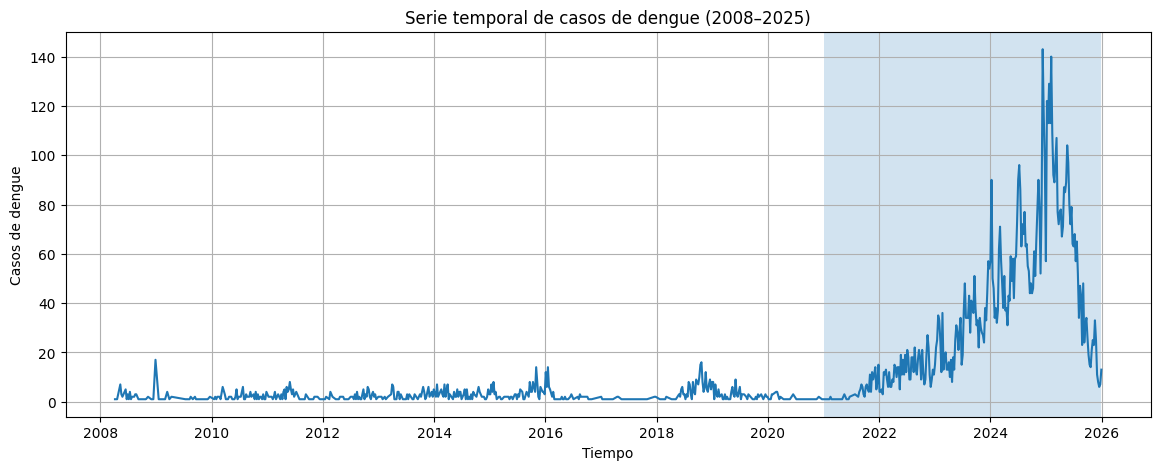

In [7]:
plt.figure(figsize=(14,5))

plt.plot(serie['semana_ep'], serie['casos_dengue'])

# sombrear periodo de análisis
plt.axvspan(pd.to_datetime('2021-01-01'), serie['semana_ep'].max(), alpha=0.2)

plt.title('Serie temporal de casos de dengue (2008–2025)')
plt.xlabel('Tiempo')
plt.ylabel('Casos de dengue')

plt.grid()
plt.show()

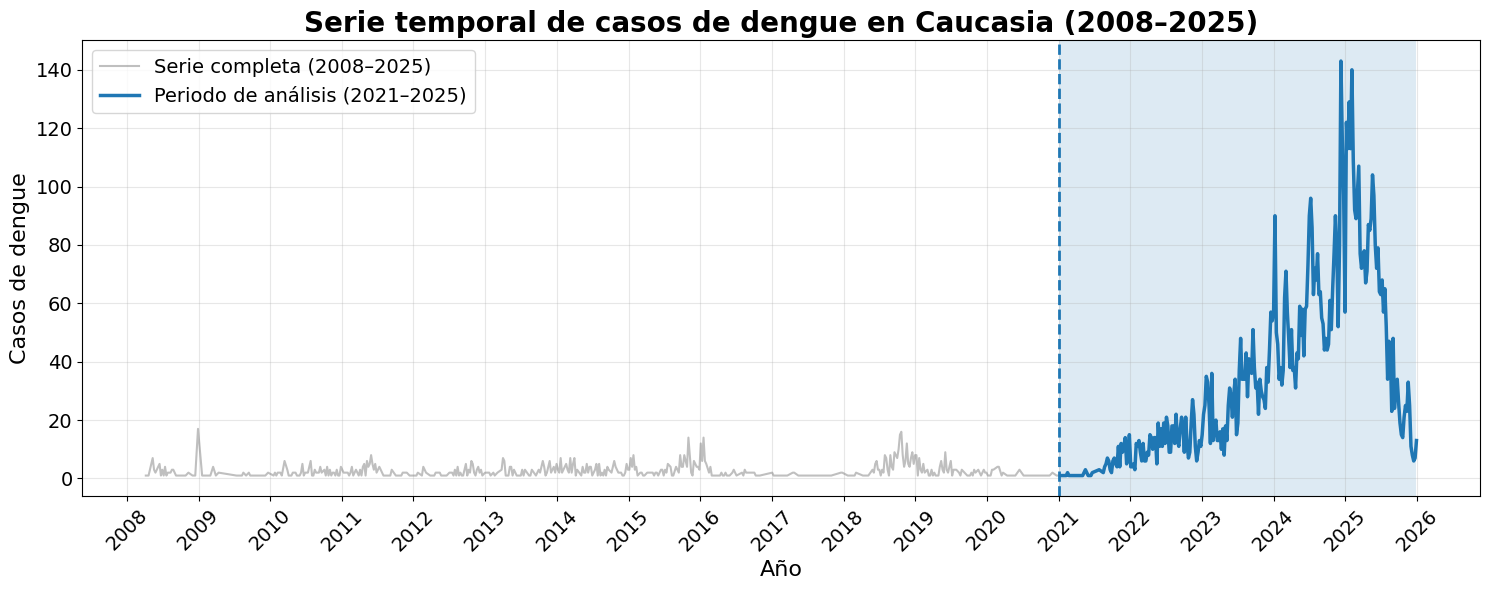

In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

plt.figure(figsize=(15,6))

# Serie completa
plt.plot(serie['semana_ep'], serie['casos_dengue'],
         color='gray', alpha=0.5, linewidth=1.5, label='Serie completa (2008–2025)')

# Periodo resaltado
mask = serie['semana_ep'] >= '2021-01-01'

plt.plot(serie.loc[mask, 'semana_ep'],
         serie.loc[mask, 'casos_dengue'],
         linewidth=2.5, label='Periodo de análisis (2021–2025)')

# Sombreado
plt.axvspan(pd.to_datetime('2021-01-01'),
            serie['semana_ep'].max(),
            alpha=0.15)

# Línea vertical
plt.axvline(pd.to_datetime('2021-01-01'),
            linestyle='--', linewidth=2)

# Formato eje X (años)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# 🔥 AUMENTO DE TAMAÑOS
plt.title('Serie temporal de casos de dengue en Caucasia (2008–2025)',
          fontsize=20, fontweight='bold')

plt.xlabel('Año', fontsize=16)
plt.ylabel('Casos de dengue', fontsize=16)

plt.xticks(rotation=45, fontsize=14)
plt.yticks(fontsize=14)

plt.legend(fontsize=14)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
df_corr= pd.read_excel(r"C:\Users\usuario1\Documents\GitHub\arima\2_ejecucion_plan_trabajo\2_consolidacion_datos_meteoro_epidemiologicos_reales\03_fusionados_y_limpieza_datos\df_final_fusionado.xlsx")
df_corr.head()

,fecha,año,semana_epi,casos_dengue,temp,temp_max,temp_min,hum_esp,hum_rel,prec,dias_lluvia,vel_vi,vel_vi_max,vel_vi_min,uv,soi,sst
0,2021-01-03,2021,1,0,28.254286,34.200000,23.832857,16.367143,70.774286,7.73,1,0.124286,0.268571,0.047143,2.222857,20.067143,-1.060214
1,2021-01-10,2021,2,0,28.638571,34.910000,24.195714,17.318571,73.095714,19.18,5,0.111429,0.204286,0.038571,2.254286,18.207143,-1.058352
2,2021-01-17,2021,3,1,29.552857,36.372857,24.090000,16.122857,65.328571,0.80,0,0.122857,0.227143,0.045714,2.420000,10.847143,-0.931407
3,2021-01-24,2021,4,0,29.208571,35.978571,24.200000,16.564286,68.205714,12.81,5,0.122857,0.220000,0.035714,2.477143,15.430000,-0.837360
4,2021-01-31,2021,5,0,29.421429,35.882857,24.684286,17.311429,69.797143,18.06,3,0.117143,0.225714,0.030000,2.290000,9.348571,-0.897892


In [15]:
df_corr.columns

Index(['fecha', 'año', 'semana_epi', 'casos_dengue', 'temp', 'temp_max',
       'temp_min', 'hum_esp', 'hum_rel', 'prec', 'dias_lluvia', 'vel_vi',
       'vel_vi_max', 'vel_vi_min', 'uv', 'soi', 'sst'],
      dtype='object')

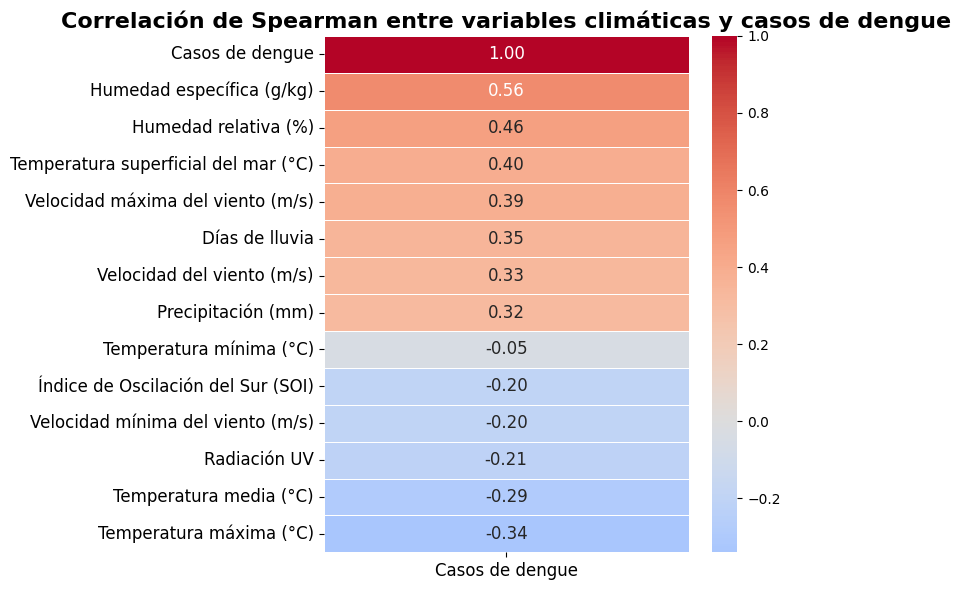

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Renombrar variables
df_corr_renombrado = df_corr.rename(columns={
    'casos_dengue': 'Casos de dengue',
    'temp': 'Temperatura media (°C)',
    'temp_max': 'Temperatura máxima (°C)',
    'temp_min': 'Temperatura mínima (°C)',
    'hum_esp': 'Humedad específica (g/kg)',
    'hum_rel': 'Humedad relativa (%)',
    'prec': 'Precipitación (mm)',
    'dias_lluvia': 'Días de lluvia',
    'vel_vi': 'Velocidad del viento (m/s)',
    'vel_vi_max': 'Velocidad máxima del viento (m/s)',
    'vel_vi_min': 'Velocidad mínima del viento (m/s)',
    'uv': 'Radiación UV',
    'soi': 'Índice de Oscilación del Sur (SOI)',
    'sst': 'Temperatura superficial del mar (°C)'
})

# 🔹 Variables a usar
variables = [
    'Casos de dengue',
    'Temperatura media (°C)',
    'Temperatura máxima (°C)',
    'Temperatura mínima (°C)',
    'Humedad específica (g/kg)',
    'Humedad relativa (%)',
    'Precipitación (mm)',
    'Días de lluvia',
    'Velocidad del viento (m/s)',
    'Velocidad máxima del viento (m/s)',
    'Velocidad mínima del viento (m/s)',
    'Radiación UV',
    'Índice de Oscilación del Sur (SOI)',
    'Temperatura superficial del mar (°C)'
]

# 🔹 Correlación de Spearman
corr = df_corr_renombrado[variables].corr(method='spearman')

# 🔹 Solo contra casos de dengue
corr_casos = corr[['Casos de dengue']].sort_values(by='Casos de dengue', ascending=False)

# 🔹 Gráfico
plt.figure(figsize=(8,6))

sns.heatmap(corr_casos,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={"size":12})

plt.title('Correlación de Spearman entre variables climáticas y casos de dengue',
          fontsize=16, fontweight='bold')

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

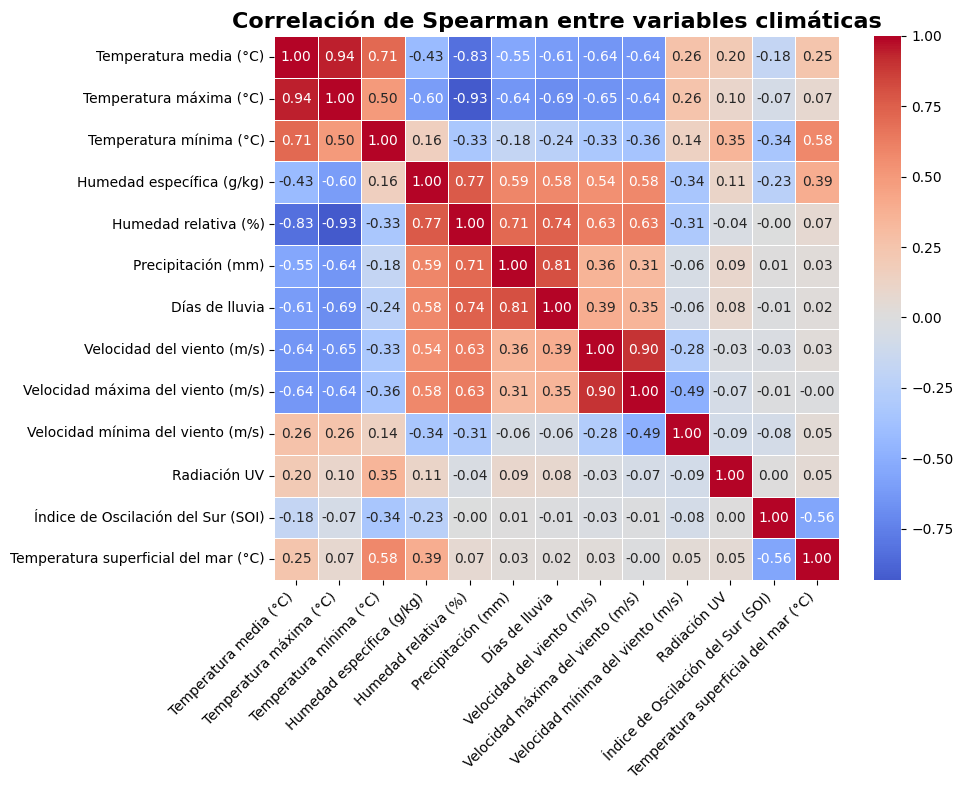

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# 🔹 Renombrar variables
df_corr_renombrado = df_corr.rename(columns={
    'casos_dengue': 'Casos de dengue',
    'temp': 'Temperatura media (°C)',
    'temp_max': 'Temperatura máxima (°C)',
    'temp_min': 'Temperatura mínima (°C)',
    'hum_esp': 'Humedad específica (g/kg)',
    'hum_rel': 'Humedad relativa (%)',
    'prec': 'Precipitación (mm)',
    'dias_lluvia': 'Días de lluvia',
    'vel_vi': 'Velocidad del viento (m/s)',
    'vel_vi_max': 'Velocidad máxima del viento (m/s)',
    'vel_vi_min': 'Velocidad mínima del viento (m/s)',
    'uv': 'Radiación UV',
    'soi': 'Índice de Oscilación del Sur (SOI)',
    'sst': 'Temperatura superficial del mar (°C)'
})

# 🔹 Variables SOLO climáticas (sin casos de dengue)
variables_climaticas = [
    'Temperatura media (°C)',
    'Temperatura máxima (°C)',
    'Temperatura mínima (°C)',
    'Humedad específica (g/kg)',
    'Humedad relativa (%)',
    'Precipitación (mm)',
    'Días de lluvia',
    'Velocidad del viento (m/s)',
    'Velocidad máxima del viento (m/s)',
    'Velocidad mínima del viento (m/s)',
    'Radiación UV',
    'Índice de Oscilación del Sur (SOI)',
    'Temperatura superficial del mar (°C)'
]

# 🔹 Correlación entre variables climáticas
corr = df_corr_renombrado[variables_climaticas].corr(method='spearman')

# 🔹 Gráfico
plt.figure(figsize=(10,8))

sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            annot_kws={"size":10})

plt.title('Correlación de Spearman entre variables climáticas',
          fontsize=16, fontweight='bold')

plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()